# **Prophet ile Satış Tahmin Modeli**

# Giriş

Bu proje, Almanya'da bulunan 1115 farklı Rossmann mağazasından birinin satış verileri aracılığıyla prophet modeli kullanılarak ileriye dönük 6 haftalık günlük satış tahminlemesi üretmek amacıyla geliştirilmiştir.

# Veri Hazırlığı

In [763]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

In [764]:
train = pd.read_csv('train.csv', low_memory=False)
store = pd.read_csv('store.csv')

In [765]:
train.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [766]:
store.head(10)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


In [767]:
df = pd.merge(train, store, on='Store', how='left')

In [768]:
df.shape

(1017209, 18)

In [769]:
df.head(20)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,5,2015-07-31,5651,589,1,1,0,1,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,5,2015-07-31,15344,1414,1,1,0,1,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,5,2015-07-31,8492,833,1,1,0,1,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,5,2015-07-31,8565,687,1,1,0,1,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,5,2015-07-31,7185,681,1,1,0,1,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


In [770]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [771]:
best_store = df.groupby('Store')['Sales'].count().idxmax()
df_store = df[df['Store'] == best_store]
print(f"Seçilen Mağaza: {best_store}")
print(f"Toplam kayıt: {len(df_store)}")

Seçilen Mağaza: 1
Toplam kayıt: 942


Model oluşturmak için en fazla veriye sahip olan mağaza seçildi

In [772]:
df_store.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [773]:
df_store[['CompetitionDistance' , 'CompetitionOpenSinceMonth' , 'CompetitionOpenSinceYear']]

,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear
1016095,1270.0,9.0,2008.0
1014980,1270.0,9.0,2008.0
1013865,1270.0,9.0,2008.0
1012750,1270.0,9.0,2008.0
1011635,1270.0,9.0,2008.0
...,...,...,...
4460,1270.0,9.0,2008.0
3345,1270.0,9.0,2008.0
2230,1270.0,9.0,2008.0
1115,1270.0,9.0,2008.0


Mağaza 1'in en yakın rakibi 1270 metre uzaklıkta olup
Eylül 2008'den beri faaliyettedir. Veri setimiz 2013-2015
dönemini kapsadığından rakip mağaza bu süre boyunca sabit
bir konumda bulunmaktadır. Mesafe değeri tüm gözlemler için
değişmediğinden modele dinamik bir katkı sağlamamaktadır.
Bu nedenle CompetitionDistance modele regressor olarak eklenmemelidir.

In [774]:
df_store["Promo2"].value_counts()

,count
Promo2,
0,942


Model oluşturmak için en fazla veriye sahip olan mağaza 1 seçildi ve boş satır sayısı görüntülendi. Promo2SinceWeek , Promo2SinceYear , PromoInterval sütunlarının bütün satırlarının boş olduğu görülüyor. Promo2 sütunu kontrol edildi. Tüm satırları 0 olduğundan mağaza 1'in yıllık/haftalık kampanya yapmadığı görülüyor. Bu yüzden bu sütunlar drop edilebilir, modele etkisi yoktur.

In [775]:
df_store = df_store.drop(columns=['Promo2' , 'Promo2SinceWeek' , 'Promo2SinceYear' , 'PromoInterval'])

In [776]:
pd.crosstab(df_store['StateHoliday'], df['Open'])


Open,0,1
StateHoliday,,
0,134,781
a,17,0
b,6,0
c,4,0


1 numaralı mağazanın tatil günlerinde kapalı olduğu görülüyor. Satış bulunmadığından dolayı StateHoliday sütunu da drop edilebilir

In [777]:
df_store = df_store.drop(columns=['StateHoliday'])

In [778]:
df_store['SchoolHoliday'].value_counts()

,count
SchoolHoliday,
0,749
1,193


In [779]:
pd.crosstab(df_store['SchoolHoliday'], df['Open'])

Open,0,1
SchoolHoliday,,
0,128,621
1,33,160


Okulların tatil olduğu günlerin çoğunda mağaza açık. Dolayısıyla bunun satış durumuna etkisi olabilir. EDA'de incelenmeli.

In [780]:
df_store = df_store[df_store['Open'] == 1]
df_store = df_store[df_store['Sales'] > 0]

Mağaza 1'in kapalı olduğu ve dolayısıyla satışın 0 olduğu günler analizden çıkarılmıştır.

In [781]:
df_store = df_store.drop(columns=['CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear'])

Sadece bir mağaza için tahmin geliştirildiğinden drop edilebilir.

# Keşifsel Veri Analizi (EDA)

In [782]:
df_store.shape

(781, 10)

In [783]:
df_store.dtypes

,0
Store,int64
DayOfWeek,int64
Date,datetime64[ns]
Sales,int64
Customers,int64
Open,int64
Promo,int64
SchoolHoliday,int64
StoreType,object
Assortment,object


In [784]:
df_store.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,781.0,781.000000,781,781.000000,781.000000,781.0,781.000000,781.000000
mean,1.0,3.504481,2014-04-16 02:38:33.956466176,4759.096031,564.049936,1.0,0.448143,0.204866
min,1.0,1.000000,2013-01-02 00:00:00,2362.000000,298.000000,1.0,0.000000,0.000000
25%,1.0,2.000000,2013-08-24 00:00:00,4000.000000,500.000000,1.0,0.000000,0.000000
50%,1.0,3.000000,2014-04-14 00:00:00,4647.000000,550.000000,1.0,0.000000,0.000000
75%,1.0,5.000000,2014-12-05 00:00:00,5348.000000,612.000000,1.0,1.000000,0.000000
max,1.0,6.000000,2015-07-31 00:00:00,9528.000000,1130.000000,1.0,1.000000,1.000000
std,0.0,1.714656,NaN,1012.106393,93.707476,0.0,0.497622,0.403862


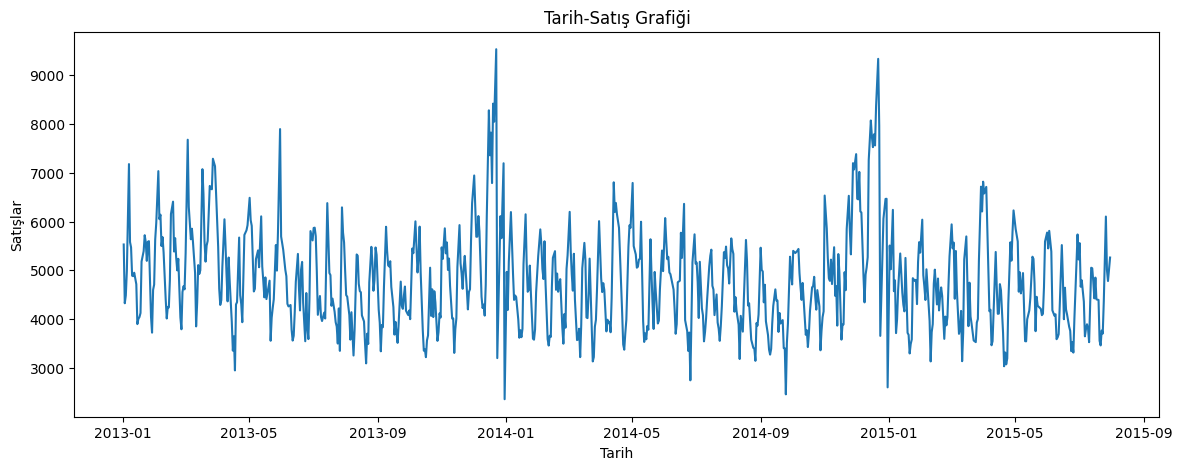

In [785]:
plt.figure(figsize=(14,5))
plt.plot(df_store['Date'] , df_store['Sales'])
plt.xlabel('Tarih')
plt.ylabel('Satışlar')
plt.title('Tarih-Satış Grafiği')
plt.show()

In [786]:
df_store['Yearly'] = df_store['Date'].dt.year
df_store['Monthly'] = df_store['Date'].dt.month
df_store['Daily'] = df_store['Date'].dt.dayofweek

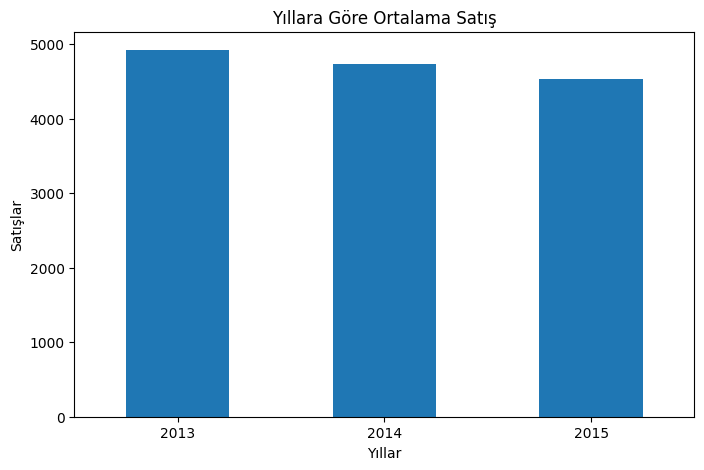

In [787]:
plt.figure(figsize=(8,5))
df_store.groupby('Yearly')['Sales'].mean().plot(kind='bar')
years = ['2013', '2014', '2015']
plt.xticks(range(3), years, rotation=0)
plt.title('Yıllara Göre Ortalama Satış')
plt.xlabel('Yıllar')
plt.ylabel('Satışlar')
plt.show()

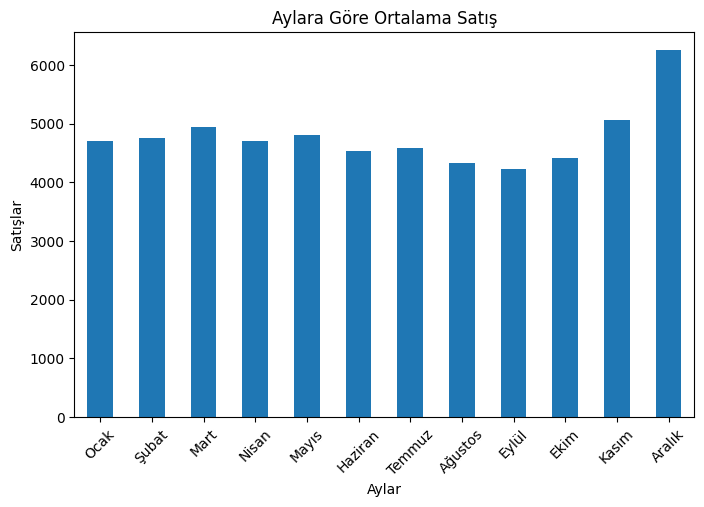

In [788]:
plt.figure(figsize=(8,5))
df_store.groupby('Monthly')['Sales'].mean().plot(kind='bar')
months = ['Ocak', 'Şubat', 'Mart', 'Nisan', 'Mayıs', 'Haziran', 'Temmuz', 'Ağustos' , 'Eylül' , 'Ekim' , 'Kasım' , 'Aralık']
plt.xticks(range(12), months, rotation=45)
plt.title('Aylara Göre Ortalama Satış')
plt.xlabel('Aylar')
plt.ylabel('Satışlar')
plt.show()

In [789]:
df_store['Daily'].unique()

array([2, 3, 4, 5, 0, 1], dtype=int32)

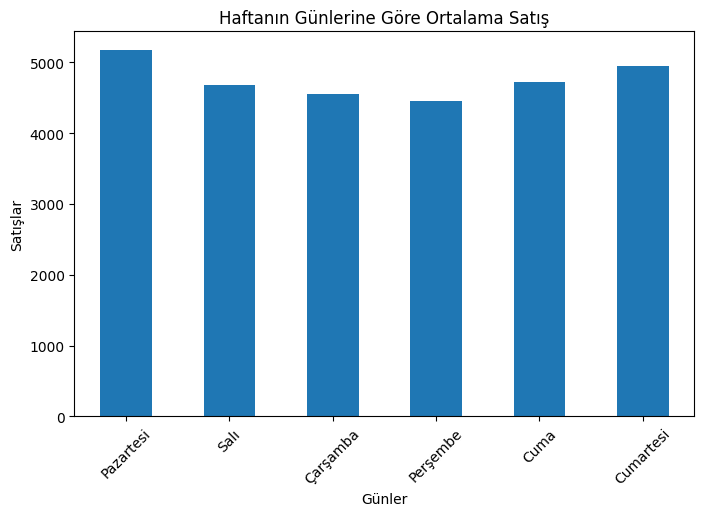

In [790]:
plt.figure(figsize=(8,5))
df_store.groupby('Daily')['Sales'].mean().plot(kind='bar')
days = ['Pazartesi', 'Salı', 'Çarşamba', 'Perşembe', 'Cuma', 'Cumartesi']
plt.xticks(range(6), days, rotation=45)
plt.title('Haftanın Günlerine Göre Ortalama Satış')
plt.xlabel('Günler')
plt.ylabel('Satışlar')
plt.show()

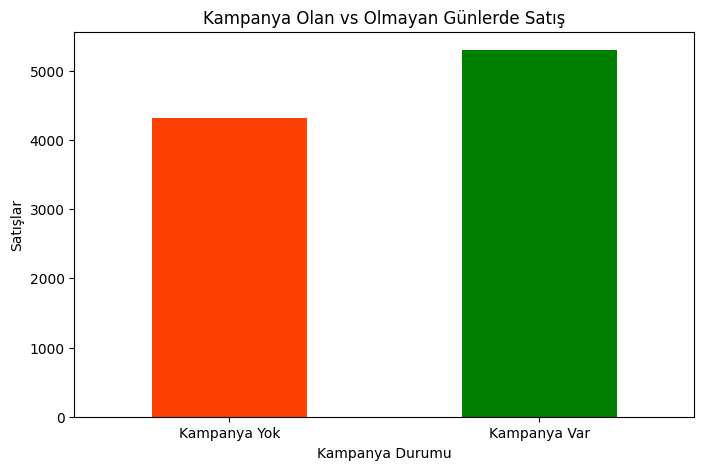

In [791]:
plt.figure(figsize=(8,5))
df_store.groupby('Promo')['Sales'].mean().plot(kind='bar' , color=['#fc4103' , 'green'])
ticks = ['Kampanya Yok', 'Kampanya Var']
plt.xticks(range(2), ticks, rotation=0)
plt.title('Kampanya Olan vs Olmayan Günlerde Satış')
plt.xlabel('Kampanya Durumu')
plt.ylabel('Satışlar')
plt.show()

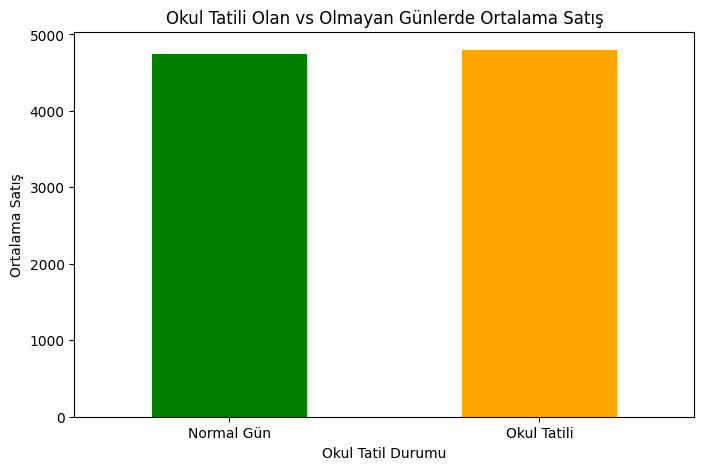

In [792]:
plt.figure(figsize=(8,5))
df_store.groupby('SchoolHoliday')['Sales'].mean().plot(kind='bar', color=['green', 'orange'])
plt.title('Okul Tatili Olan vs Olmayan Günlerde Ortalama Satış')
plt.xticks([0, 1], ['Normal Gün', 'Okul Tatili'], rotation=0)
plt.xlabel('Okul Tatil Durumu')
plt.ylabel('Ortalama Satış')
plt.show()

SchoolHoliday değişkeni incelendiğinde normal günlerle
tatil günleri arasında anlamlı bir satış farkı gözlemlenmemiştir.
Bu nedenle modele regressor olarak eklenmeyecektir.

# Decomposition Analizi

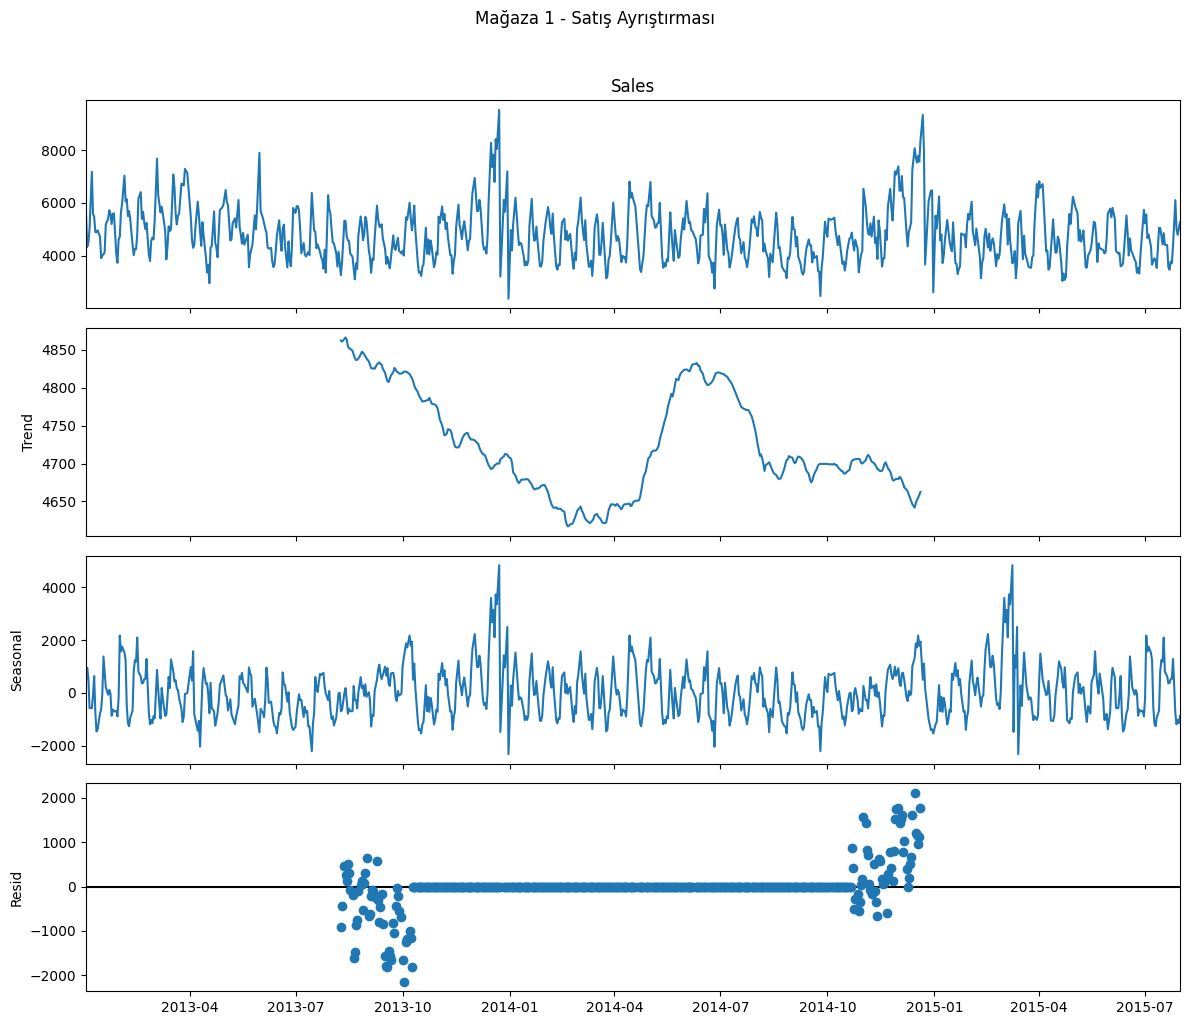

In [793]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_indexed = df_store.set_index('Date').sort_index()
result = seasonal_decompose(
    df_indexed['Sales'],
    model='additive',    # trend + mevsimsellik + gürültü toplamı
    period=365           # yıllık mevsimsellik (günlük veri olduğu için)
)

result.plot()
plt.suptitle('Mağaza 1 - Satış Ayrıştırması', y=1.02)
plt.tight_layout()
plt.show()

## Decomposition Analizi Yorumu

### Trend
Mağaza 1'in satışları uzun vadede hafif düşüş eğilimindedir.
2013 başında ~4850 seviyesinde olan trend, 2013 ortasında ~4630'a gerilemiş,
2014 ortasında tekrar ~4820'ye çıkmış ve 2014 sonu itibarıyla tekrar düşüşe geçmiştir.

### Mevsimsellik (Seasonality)
Belirgin bir yıllık mevsimsel örüntü gözlemlenmektedir.
Her yıl Ekim-Aralık döneminde satışlarda büyük zirveler oluşmaktadır.
Bu durum Noel alışveriş sezonu ile açıklanabilir.

In [794]:
mask = (df_store['Date'] >= '2013-08-01') & (df_store['Date'] <= '2013-11-01')
print(df_store[mask][['Date', 'Sales']].head(30))

             Date  Sales
779715 2013-08-01   4994
778600 2013-08-02   4494
777485 2013-08-03   4461
775255 2013-08-05   4086
774140 2013-08-06   3582
773025 2013-08-07   4143
771910 2013-08-08   3680
770795 2013-08-09   3257
769680 2013-08-10   3768
767450 2013-08-12   5326
766335 2013-08-13   5299
765220 2013-08-14   4724
764105 2013-08-15   4575
762990 2013-08-16   4552
761875 2013-08-17   4078
759645 2013-08-19   3954
758530 2013-08-20   3492
757415 2013-08-21   3096
756300 2013-08-22   3703
755185 2013-08-23   3493
754070 2013-08-24   4752
751840 2013-08-26   5482
750725 2013-08-27   5156
749610 2013-08-28   4583
748495 2013-08-29   4804
747380 2013-08-30   5469
746265 2013-08-31   5317
744035 2013-09-02   4195
742920 2013-09-03   3928
741805 2013-09-04   3343


In [795]:
mask1 = (df_store['Date'] >= '2014-11-01') & (df_store['Date'] <= '2015-01-01')
print(df_store[mask1][['Date', 'Sales']].head(30))

             Date  Sales
292480 2014-11-01   6532
290610 2014-11-03   5857
289675 2014-11-04   5253
288740 2014-11-05   4838
287805 2014-11-06   4785
286870 2014-11-07   5220
285935 2014-11-08   4720
284065 2014-11-10   5474
283130 2014-11-11   4479
282195 2014-11-12   4677
281260 2014-11-13   3869
280325 2014-11-14   5334
279390 2014-11-15   4967
277520 2014-11-17   3582
276585 2014-11-18   3890
275650 2014-11-19   3894
274715 2014-11-20   4963
273780 2014-11-21   4594
272845 2014-11-22   5849
270975 2014-11-24   6527
270040 2014-11-25   5815
269105 2014-11-26   5328
268170 2014-11-27   6144
267235 2014-11-28   7195
266300 2014-11-29   7066
264430 2014-12-01   7380
263495 2014-12-02   6467
262560 2014-12-03   6454
261625 2014-12-04   7016
260690 2014-12-05   6207


### Gürültü (Residual)
Residual panelinde gözlemlenen kümelenmeler, seasonal_decompose algoritmasının zaman serisi başlangıç ve bitiş noktalarında yaşadığı edge effect'ten kaynaklanmaktadır. Veri kalitesiyle ilgili bir sorun değildir.

# Model Kurulumu

In [796]:
test = pd.read_csv('test.csv')
test['Date'] = pd.to_datetime(test['Date'])
print(test['Date'].min(), test['Date'].max())

2015-08-01 00:00:00 2015-09-17 00:00:00


2015 Temmuz sonrası için 6 haftalık tahmin yapılacak.

In [797]:
print(df_store.columns.tolist())
print(df_store.shape)
print(df_store.head())

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'StoreType', 'Assortment', 'Yearly', 'Monthly', 'Daily']
(781, 13)
         Store  DayOfWeek       Date  Sales  Customers  Open  Promo  \
1014980      1          3 2013-01-02   5530        668     1      0   
1013865      1          4 2013-01-03   4327        578     1      0   
1012750      1          5 2013-01-04   4486        619     1      0   
1011635      1          6 2013-01-05   4997        635     1      0   
1009405      1          1 2013-01-07   7176        785     1      1   

         SchoolHoliday StoreType Assortment  Yearly  Monthly  Daily  
1014980              1         c          a    2013        1      2  
1013865              1         c          a    2013        1      3  
1012750              1         c          a    2013        1      4  
1011635              1         c          a    2013        1      5  
1009405              1         c          a    2013        1      0  

In [798]:
prophet_df = df_store[['Date', 'Sales', 'Promo']].rename(
    columns={'Date': 'ds', 'Sales': 'y'}
)

print(prophet_df.shape)
print(prophet_df.head())

(781, 3)
                ds     y  Promo
1014980 2013-01-02  5530      0
1013865 2013-01-03  4327      0
1012750 2013-01-04  4486      0
1011635 2013-01-05  4997      0
1009405 2013-01-07  7176      1


In [799]:
train_df = prophet_df[prophet_df['ds'] < '2015-07-01']
test_df = prophet_df[prophet_df['ds'] >= '2015-07-01']

print(f"Train: {len(train_df)} kayıt")
print(f"Test: {len(test_df)} kayıt")

Train: 754 kayıt
Test: 27 kayıt


In [800]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model.add_regressor('Promo')

model.fit(train_df)

In [801]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    model,
    initial='500 days', period='90 days', horizon='30 days')

df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mae', 'rmse', 'mape']].head(30))

INFO:prophet:Making 5 forecasts with cutoffs between 2014-06-05 00:00:00 and 2015-05-31 00:00:00


  0%|          | 0/5 [00:00<?, ?it/s]

   horizon         mae         rmse      mape
0   3 days  484.483289   535.569149  0.091370
1   4 days  440.614961   523.143305  0.083068
2   5 days  467.447998   556.668704  0.095877
3   6 days  477.290652   577.681245  0.105486
4   7 days  586.477744   670.272987  0.138930
5   8 days  463.659531   582.987907  0.112004
6   9 days  317.317949   411.087129  0.075280
7  10 days  310.467862   379.230202  0.075062
8  11 days  364.021076   427.344506  0.084507
9  12 days  441.310714   523.749239  0.097776
10 13 days  449.680462   505.648092  0.090979
11 14 days  435.601183   488.150354  0.085084
12 15 days  497.659941   598.299240  0.096107
13 16 days  627.902214   755.918635  0.131047
14 17 days  637.687239   751.646254  0.141185
15 18 days  698.137218   837.769502  0.150068
16 19 days  647.883240   806.236962  0.143818
17 20 days  812.984719  1138.967530  0.153275
18 21 days  859.610694  1197.492377  0.168142
19 22 days  934.231005  1241.535698  0.213734
20 23 days  719.669758   953.22349

### Cross Validation Sonuçları

Model, 2014-2015 dönemi boyunca 5 farklı zaman diliminde test edilmiştir.
30 günlük tahmin ufkunda MAPE değerleri genel olarak %8-10 bandında seyretmiştir.

Ancak 30 günlük cross validation çıktısı incelendiğinde belirgin bir örüntü
dikkat çekmektedir: 7. günde %13.8, 14. günde %14.1, 21. günde %21.3 ile
hafta geçiş noktalarında MAPE değerleri sistematik olarak yükselmektedir.
Bu durum modelin haftalık mevsimsellik sınırlarında kısa vadeli
dalgalanmaları tam olarak yakalayamadığına işaret etmektedir.

Hafta geçişlerinin ardından MAPE tekrar normale döndüğünden bu sınırlılık
modelin genel güvenilirliğini bozmamaktadır.

In [802]:
metrics = {'Metrik': ['MAE', 'RMSE', 'MAPE'],
           'Değer': [318.43, 406.85, '7.12%']}
pd.DataFrame(metrics)

,Metrik,Değer
0,MAE,318.43
1,RMSE,406.85
2,MAPE,7.12%


In [803]:
future = model.make_future_dataframe(periods=48, freq='D')
# Train'deki Promo değerleri alındı
future = future.merge(
    prophet_df[['ds', 'Promo']],
    on='ds',
    how='left'
)

# Gelecek günler için Promo bilinmiyor o yüzden 0 kabul edildi.
future['Promo'] = future['Promo'].fillna(0)

In [804]:
forecast = model.predict(future)

In [805]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(20))

            ds         yhat   yhat_lower   yhat_upper
782 2015-07-29  4786.069964  3957.894294  5532.532509
783 2015-07-30  4643.913067  3884.976398  5469.101396
784 2015-07-31  4906.112307  4145.504635  5707.393720
785 2015-08-01  4482.663198  3691.136149  5298.145101
786 2015-08-02  3918.023460  3184.902645  4700.877049
787 2015-08-03  3935.927289  3183.523751  4731.089185
788 2015-08-04  3466.867478  2655.395646  4237.906147
789 2015-08-05  3321.486449  2541.892954  4164.560965
790 2015-08-06  3185.037436  2386.984642  3991.423320
791 2015-08-07  3457.432017  2646.872368  4220.387189
792 2015-08-08  4285.629573  3451.011926  5082.880093
793 2015-08-09  3739.867630  2936.526983  4605.803327
794 2015-08-10  3779.982836  2921.245749  4620.938193
795 2015-08-11  3336.307712  2464.232252  4080.909521
796 2015-08-12  3218.515718  2409.767031  4016.431412
797 2015-08-13  3111.260115  2324.472998  3942.434760
798 2015-08-14  3413.530797  2591.652173  4239.078840
799 2015-08-15  4271.438286 

In [806]:
forecast_test = forecast[forecast['ds'] >= '2015-07-01'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

comparison = test_df.merge(forecast_test, on='ds', how='left')
print(comparison.head(10))

          ds     y  Promo         yhat   yhat_lower   yhat_upper
0 2015-07-01  5223      1  4682.938947  3918.643996  5481.682980
1 2015-07-02  5558      1  4572.385403  3748.519104  5358.892539
2 2015-07-03  4665      1  4871.046590  4103.308826  5623.593579
3 2015-07-04  4797      0  4486.578646  3638.471665  5287.430383
4 2015-07-06  4359      0  4025.867580  3289.767278  4878.962349
5 2015-07-07  3650      0  3601.551093  2834.182701  4361.449369
6 2015-07-08  3797      0  3501.499656  2689.125702  4365.853051
7 2015-07-09  3897      0  3409.495279  2602.253625  4209.763134
8 2015-07-10  3808      0  3725.084604  2941.779271  4561.839885
9 2015-07-11  3530      0  4594.499520  3850.541391  5394.850925


In [807]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(comparison['y'], comparison['yhat'])
rmse = np.sqrt(mean_squared_error(comparison['y'], comparison['yhat']))
mape = np.mean(np.abs((comparison['y'] - comparison['yhat']) / comparison['y'])) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  318.43
RMSE: 406.85
MAPE: 7.12%


##Model Performansı
Model, gerçek satış değerlerinden ortalama %7.12 sapma göstermiştir. Perakende satış tahmininde %10 altı mükemmel kabul edildiğinden
model başarılı bir performans sergilemiştir.

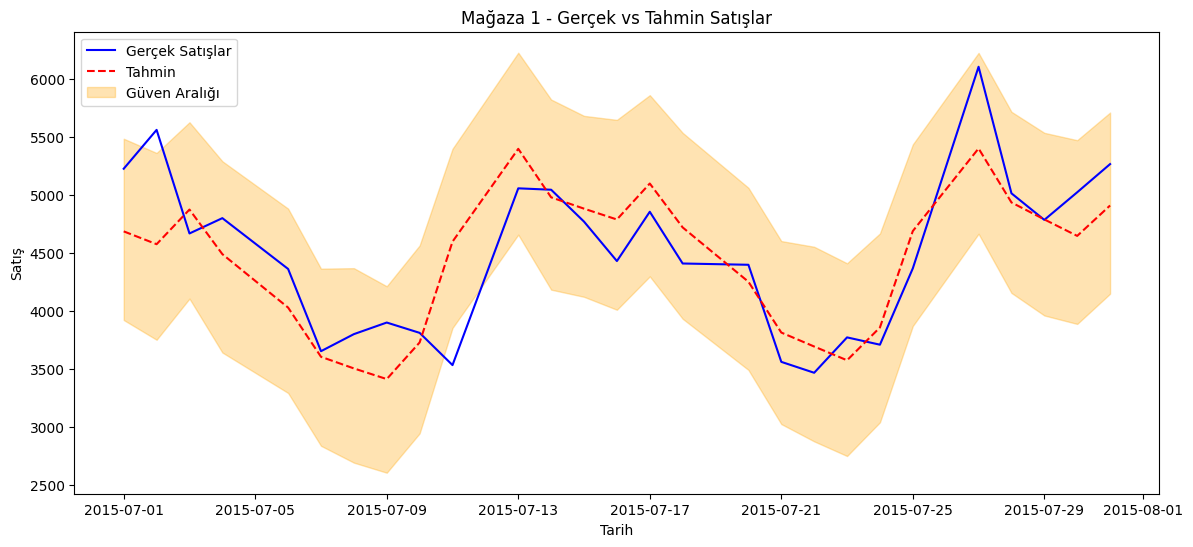

In [808]:
plt.figure(figsize=(14, 6))
plt.plot(comparison['ds'], comparison['y'],
         label='Gerçek Satışlar', color='blue')
plt.plot(comparison['ds'], comparison['yhat'],
         label='Tahmin', color='red', linestyle='--')
plt.fill_between(comparison['ds'],
                 comparison['yhat_lower'],
                 comparison['yhat_upper'],
                 alpha=0.3, color='orange', label='Güven Aralığı')
plt.title('Mağaza 1 - Gerçek vs Tahmin Satışlar')
plt.xlabel('Tarih')
plt.ylabel('Satış')
plt.legend()
plt.show()

## Gerçek vs Tahmin Grafiği Yorumu

Model, Temmuz 2015 dönemindeki gerçek satışları başarıyla tahmin etmiştir.
Haftalık mevsimsellik örüntüleri doğru yakalanmış, gerçek satış değerlerinin
büyük çoğunluğu güven aralığı içinde kalmıştır. %7.12 MAPE değeri grafikte
de görsel olarak doğrulanmaktadır.

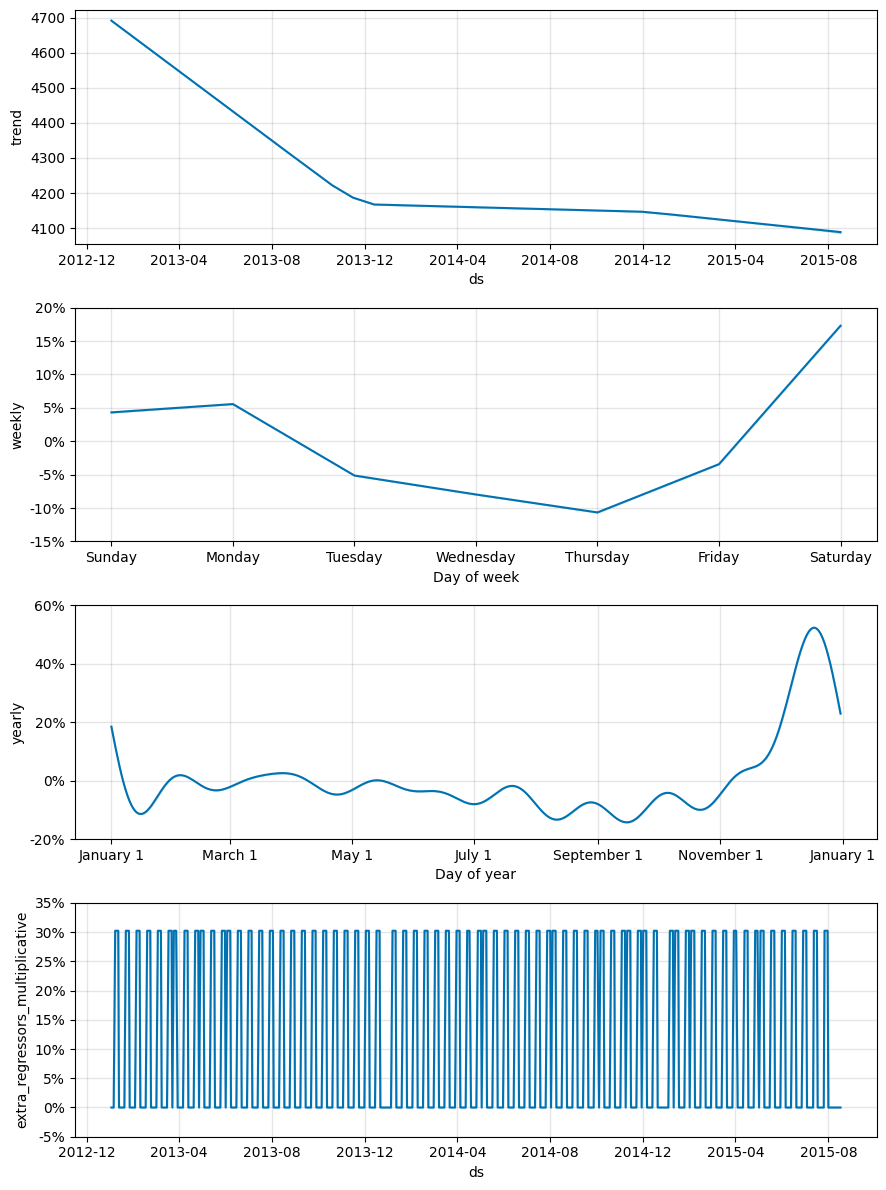

In [809]:
model.plot_components(forecast)
plt.show()

## Model Bileşenleri Yorumu

- **Trend:** Satışlar 2013'te düşüş göstermiş, 2014 sonrası stabilleşmiştir.
- **Haftalık:** Cumartesi en yüksek (%17), Perşembe en düşük (%-10) satış günüdür.
- **Yıllık:** Aralık ayında Noel sezonu nedeniyle %50'ye yakın artış gözlemlenmektedir.
- **Promosyon:** Promosyon günlerinde satışlar %30 artmaktadır.

#  Genel Rapor

## Proje Amacı
Rossmann mağaza zincirinin geçmiş satış verileri kullanılarak
Meta Prophet modeli ile gelecek dönem satış tahmini yapılması
ve modelin performansının değerlendirilmesi.

## Veri Seti
- **Kaynak:** Rossmann Store Sales (Kaggle)
- **Kapsam:** Mağaza 1, 2013-2015 dönemi
- **Toplam Kayıt:** 781 gün (kapalı günler çıkarıldıktan sonra)
- **Train/Test:** 754 / 27 kayıt

## Veri Hazırlığı
- Kapalı mağaza günleri (Open=0) ve sıfır satış kayıtları veri setinden çıkarıldı
- Tatil günlerinde (StateHoliday) mağazanın kapalı olduğu tespit edildi
- SchoolHoliday değişkeninin satışlar üzerinde anlamlı etkisi gözlemlenmedi
- Rakip mağaza mesafesi (1270m) tüm dönem boyunca sabit kaldığından
  modele eklenmedi

## Model
- **Algoritma:** Prophet
- **Mevsimsellik:** Yıllık + Haftalık
- **Regressor:** Promo (promosyon günleri)
- **Mod:** Multiplicative

## Performans Sonuçları

| Metrik | Değer |
|--------|-------|
| MAE    | 318.43 |
| RMSE   | 406.85 |
| MAPE   | %7.12  |

## Temel Bulgular
- Mağaza satışları uzun vadede hafif düşüş trendindedir
- Cumartesi en yüksek, Perşembe en düşük satış günüdür
- Aralık ayında Noel sezonu nedeniyle %50'ye yakın satış artışı gözlemlenmektedir
- Promosyon günlerinde satışlar ortalama %30 artmaktadır
- Model gerçek satışlardan ortalama %7.12 sapma göstermiş olup
  perakende sektöründe mükemmel kabul edilen %10 eşiğinin altındadır

## Sonuç
Prophet modeli Rossmann Mağaza 1'in satış örüntülerini başarıyla
öğrenmiş ve gelecek dönem tahminlerini yüksek doğrulukla üretmiştir.
Haftalık ve yıllık mevsimsellik bileşenleri net biçimde yakalanmış,
promosyon etkisi modele başarıyla entegre edilmiştir.